In [ ]:
from tensorflow.keras.datasets import mnist


In [ ]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

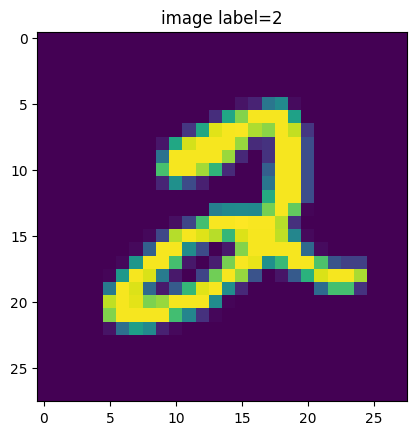

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[5])
plt.title(f"image label={y_train[5]}")
plt.show( )

normalising the data

In [ ]:
X_train= x_train /255
Y_test = y_test/255


In [ ]:
Y_train=to_categorical(y_train,num_classes=10)
Y_test=to_categorical(y_test,num_classes=10)

hidden layer creation


In [ ]:
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

model creation

In [ ]:
model= Sequential([
    Flatten(input_shape = (28,28)),
    Dense(5,activation = 'relu'),
    Dense(10,activation='softmax')

])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


summary of model

In [ ]:
model.summary (

)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,985 (15.57 KB)

 Trainable params: 3,985 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

compiling our model

In [ ]:
model.compile(
    optimizer='adam',#just like gradient decscent
    loss= 'categorical_crossentropy',
    metrics=['accuracy']
)

model fitting


In [ ]:
model.fit(X_train,Y_train,epochs=10,batch_size=32,verbose=1)
# verbose = 0: Silent mode. No output is printed during training.
# verbose = 1: Progress bar. A progress bar is displayed, showing the overall progress of the training epochs.
# verbose = 2: One line per epoch. For each epoch, a single line is printed summarizing the training loss and metrics.

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9055 - loss: 0.3381
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9075 - loss: 0.3303
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9083 - loss: 0.3243
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9054 - loss: 0.3359
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9103 - loss: 0.3161
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9071 - loss: 0.3284
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9066 - loss: 0.3335
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9047 - loss: 0.3310
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9090 - loss: 0.3192
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9087 - loss: 0.3266


Evaluate the model

In [ ]:
model.evaluate(x_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7977 - loss: 109.8697


[97.34891510009766, 0.8222000002861023]

Saving our model



> This line is responsible for saving your trained Keras model to a file named mnist.h5. Let's understand the components:

model: This refers to your Keras model object, which you've created and trained. It contains the architecture (layers, activation functions) and the learned weights of your neural network.

save(): This is a method provided by Keras models to save the model to disk. It essentially serializes the entire model into a file, preserving its structure and learned parameters.

'mnist.h5': This is a string specifying the filename and format to save the model in. The .h5 extension signifies that the model will be saved in the HDF5 format, a widely used format for storing large datasets and complex objects like neural networks.

In essence, model.save('mnist.h5') does the following:

Takes your trained model object.
Serializes it into the HDF5 format.
Stores it in a file named mnist.h5 in your current working directory.
Why is this important?

Saving your model allows you to:

Reuse it later: You can load the saved model later without retraining, allowing you to quickly use your model for predictions or further training.
Share it: You can share your trained model with others, enabling them to utilize your work without having to train the model from scratch.
Checkpoint your progress: You can save the model at different stages of training to create checkpoints, enabling you to resume training from a specific point if necessary.
To load your saved model, you would use:

from tensorflow import keras

loaded_model = keras.models.load_model('mnist.h5')



In [ ]:
model.save('mnist.h5')

To load your saved model, you would use:

In [ ]:
# from tensorflow import keras

# loaded_model = keras.models.load_model('mnist.h5')

weights of our nn

In [ ]:
model.get_weights()

[array([[ 0.06167574, -0.00135472,  0.08162719,  0.03636079, -0.05020559],
        [-0.07097185,  0.00028561,  0.01285731, -0.05468713, -0.02230474],
        [ 0.0841243 , -0.05642999,  0.03145043,  0.05065574,  0.083575  ],
        ...,
        [-0.06463721, -0.0139193 , -0.01575203,  0.06087068, -0.03936618],
        [ 0.05226956, -0.05131299,  0.05225043, -0.04539071,  0.01368594],
        [ 0.07337344,  0.05735715,  0.01926161, -0.04038873,  0.03577907]],
       dtype=float32),
 array([-0.09901888,  1.2585157 ,  0.5885068 , -0.3688086 ,  0.47229186],
       dtype=float32),
 array([[-0.40754908,  0.7328619 , -0.04434976,  0.7684588 , -0.8253191 ,
          0.4659388 , -0.19699816, -1.5069963 ,  0.4136921 , -0.54223484],
        [-1.0502075 ,  0.11238777, -0.7514111 , -0.83254915,  0.8708295 ,
         -0.5942239 , -0.20064151,  0.24196646,  0.08210821,  0.6080743 ],
        [ 0.59460586, -1.4183291 , -0.56202006,  0.03935764, -0.4913932 ,
          0.25487688, -1.1022143 ,  0.587822